<a href="https://colab.research.google.com/github/matiaslezama08/tesis_violencia_domestica/blob/pruebas_matias/Modelo_DV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyreadstat

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import pyreadstat
import os
import glob

# Ruta de tu carpeta en Drive
ruta = "/content/drive/MyDrive/TESIS_DV"

# Ver archivos dentro de la carpeta
archivos = os.listdir(ruta)
print(archivos)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['RECH0_2019.SAV', 'RECH1_2019.sav', 'RECH4_2019.sav', 'RECH23_2019.SAV', 'Programas_sociales_hogar_2019.SAV', 'PS_BECA18_2019.SAV', 'PS_TRABAJA_2019.SAV', 'PS_PENSION65_2019.SAV', 'PS_VL_2019.sav', 'PS_COMEDOR_2019.SAV', 'PS_WAWAWASI_2019.sav', 'PS_QALIWARMA_2019.SAV', 'REC91_2019.sav', 'REC0111_2019.sav', 'RE516171_2019.sav', 'REC84DV_2019.sav', 'RECHM_2019.sav', 'PS_BECA18_2020.csv', 'PS_COMEDOR_2020.csv', 'PS_VL_2020.csv', 'PS_QALIWARMA_2020.csv', 'Programas_Sociales_Hogar_2020.csv', 'PS_TRABAJA_2020.csv', 'PS_WAWAWASI_2020.csv', 'PS_PENSION65_2020.csv', 'RE516171_2020.csv', 'REC0111_2020.csv', 'REC84DV_2020.csv', 'REC91_2020.csv', 'RECH0_2020.csv', 'RECH1_2020.csv', 'RECH23_2020.csv', 'RECH4_2020.csv', 'RECHM_2020.csv', 'Programas_Sociales_Hogar_2021.csv', 'PS_VL_2021.csv', 'PS_COMEDOR_2021.csv', 'PS_TRABAJA_2021.csv', 'PS_WAWAWASI_2021.csv', 'PS_BECA18_

In [ ]:
# Convertir los nombres de archivos en rutas completas
archivos_ruta = [os.path.join(ruta, archivo) for archivo in archivos]

archivos_ruta

['/content/drive/MyDrive/TESIS_DV/RECH0_2019.SAV',
 '/content/drive/MyDrive/TESIS_DV/RECH1_2019.sav',
 '/content/drive/MyDrive/TESIS_DV/RECH4_2019.sav',
 '/content/drive/MyDrive/TESIS_DV/RECH23_2019.SAV',
 '/content/drive/MyDrive/TESIS_DV/Programas_sociales_hogar_2019.SAV',
 '/content/drive/MyDrive/TESIS_DV/PS_BECA18_2019.SAV',
 '/content/drive/MyDrive/TESIS_DV/PS_TRABAJA_2019.SAV',
 '/content/drive/MyDrive/TESIS_DV/PS_PENSION65_2019.SAV',
 '/content/drive/MyDrive/TESIS_DV/PS_VL_2019.sav',
 '/content/drive/MyDrive/TESIS_DV/PS_COMEDOR_2019.SAV',
 '/content/drive/MyDrive/TESIS_DV/PS_WAWAWASI_2019.sav',
 '/content/drive/MyDrive/TESIS_DV/PS_QALIWARMA_2019.SAV',
 '/content/drive/MyDrive/TESIS_DV/REC91_2019.sav',
 '/content/drive/MyDrive/TESIS_DV/REC0111_2019.sav',
 '/content/drive/MyDrive/TESIS_DV/RE516171_2019.sav',
 '/content/drive/MyDrive/TESIS_DV/REC84DV_2019.sav',
 '/content/drive/MyDrive/TESIS_DV/RECHM_2019.sav',
 '/content/drive/MyDrive/TESIS_DV/PS_BECA18_2020.csv',
 '/content/drive/

In [ ]:
# ============================================================
# 1. FUNCIONES BASE PARA LEER ARCHIVOS ENDES
# ============================================================

import os
import pandas as pd
import pyreadstat

def leer_archivo(path):
    """
    Lee archivos .sav o .csv de ENDES.
    Devuelve un DataFrame con nombres de columnas en mayúscula y sin espacios.
    """
    ext = os.path.splitext(path)[1].lower()

    if ext == ".sav":
        df, meta = pyreadstat.read_sav(path, apply_value_formats=False)
    elif ext == ".csv":
        df = pd.read_csv(path, low_memory=False)
    else:
        raise ValueError(f"Formato no soportado: {path}")

    df.columns = df.columns.str.upper().str.strip()

    # Normalizamos llaves si existen
    for col in ["CASEID", "HHID"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

    return df


def buscar_archivo(ruta, patron):
    """
    Busca un archivo dentro de la carpeta de Drive usando parte del nombre.
    Ejemplo: buscar_archivo(ruta, "REC84DV_2020")
    """
    encontrados = [
        os.path.join(ruta, f)
        for f in os.listdir(ruta)
        if patron.upper() in f.upper()
    ]

    if len(encontrados) == 0:
        print(f"No encontré archivo con patrón: {patron}")
        return None

    if len(encontrados) > 1:
        print(f"Encontré varios archivos para {patron}:")
        for e in encontrados:
            print(" -", os.path.basename(e))

    return encontrados[0]

In [ ]:
# ============================================================
# 2. VERIFICAR ARCHIVOS PRINCIPALES POR AÑO
# ============================================================

anios = [2019, 2020, 2021, 2022, 2023, 2024]

for anio in anios:
    print("\nAño:", anio)

    archivo_dv = buscar_archivo(ruta, f"REC84DV_{anio}")
    archivo_ind = buscar_archivo(ruta, f"REC0111_{anio}")

    print("Violencia:", os.path.basename(archivo_dv) if archivo_dv else "NO ENCONTRADO")
    print("Individual:", os.path.basename(archivo_ind) if archivo_ind else "NO ENCONTRADO")


Año: 2019
Violencia: REC84DV_2019.sav
Individual: REC0111_2019.sav

Año: 2020
Violencia: REC84DV_2020.csv
Individual: REC0111_2020.csv

Año: 2021
Violencia: REC84DV_2021.csv
Individual: REC0111_2021.csv

Año: 2022
Violencia: REC84DV_2022.csv
Individual: REC0111_2022.csv

Año: 2023
Violencia: REC84DV_2023.csv
Individual: REC0111_2023.csv

Año: 2024
Violencia: REC84DV_2024.csv
Individual: REC0111_2024.csv


In [ ]:
# ============================================================
# 3. PRUEBA DE LECTURA: AÑO 2024
# ============================================================

archivo_dv_2024 = buscar_archivo(ruta, "REC84DV_2024")
archivo_ind_2024 = buscar_archivo(ruta, "REC0111_2024")

dv_2024 = leer_archivo(archivo_dv_2024)
ind_2024 = leer_archivo(archivo_ind_2024)

print("REC84DV 2024:", dv_2024.shape)
print("REC0111 2024:", ind_2024.shape)

print("\nColumnas REC84DV:")
print(dv_2024.columns.tolist()[:30])

print("\nColumnas REC0111:")
print(ind_2024.columns.tolist()[:30])

REC84DV 2024: (34252, 220)
REC0111 2024: (37117, 104)

Columnas REC84DV:
['ID1', 'CASEID', 'D101A', 'D101B', 'D101C', 'D101D', 'D101E', 'D101F', 'D101G', 'D101H', 'D101I', 'D101J', 'D102', 'D103A', 'D103B', 'D103C', 'D103D', 'D103E', 'D103F', 'D104', 'D105A', 'D105B', 'D105C', 'D105D', 'D105E', 'D105F', 'D105G', 'D105H', 'D105I', 'D105J']

Columnas REC0111:
['ID1', 'CASEID', 'HHID', 'V001', 'V002', 'V003', 'V004', 'V007', 'V008', 'V009', 'V010', 'V011', 'V012', 'V013', 'V014', 'V015', 'V017', 'V018', 'V019', 'V019A', 'V020', 'V021', 'V023', 'V024', 'V025', 'V026', 'V027', 'V028', 'V029', 'V030']


In [ ]:
# CONSTRUIR VARIABLE DEPENDIENTE IPV


def construir_ipv(df):
    """
    Construye variables de violencia a partir de REC84DV.

    IPV global = 1 si hubo violencia emocional, física o sexual.
    Física = D106 o D107.
    Emocional = D104.
    Sexual = D108.

    Si D104, D106, D107 y D108 están todas perdidas,
    se deja ipv_global como NA para no confundir no respuesta
    con ausencia de violencia.
    """
    df = df.copy()

    necesarias = ["D104", "D106", "D107", "D108"]
    faltantes = [c for c in necesarias if c not in df.columns]

    if faltantes:
        raise ValueError(f"Faltan variables para construir IPV: {faltantes}")

    for c in necesarias:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df["viol_emocional"] = (df["D104"] == 1).astype("Int64")
    df["viol_fisica"] = ((df["D106"] == 1) | (df["D107"] == 1)).astype("Int64")
    df["viol_sexual"] = (df["D108"] == 1).astype("Int64")

    df["ipv_global"] = (
        (df["viol_emocional"] == 1) |
        (df["viol_fisica"] == 1) |
        (df["viol_sexual"] == 1)
    ).astype("Int64")

    # Si no hay información válida en ninguna variable de violencia,
    # no lo tratamos como 0, sino como perdido.
    sin_info = df[necesarias].isna().all(axis=1)

    cols_y = ["viol_emocional", "viol_fisica", "viol_sexual", "ipv_global"]
    df.loc[sin_info, cols_y] = pd.NA

    return df

In [ ]:
dv_2024 = leer_archivo(archivo_dv_2024)
dv_2024 = construir_ipv(dv_2024)

dv_2024[["D104", "D106", "D107", "D108",
         "viol_emocional", "viol_fisica", "viol_sexual", "ipv_global"]].head()

,D104,D106,D107,D108,viol_emocional,viol_fisica,viol_sexual,ipv_global
0,0.0,1.0,0.0,0.0,0,1,0,1
1,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>
2,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>
3,0.0,0.0,0.0,0.0,0,0,0,0
4,0.0,0.0,0.0,0.0,0,0,0,0


In [ ]:
# ============================================================
# 4. DEFINIR VARIABLES DEL MODELO
# ============================================================

# Años de análisis
anios = [2019, 2020, 2021, 2022, 2023, 2024]

# Variable dependiente
y_var = "ipv_global"

# Variables que vienen del módulo de violencia REC84DV
# OJO: no incluimos D104, D106, D107, D108 como predictoras
# porque esas construyen la variable dependiente.
vars_dv = [
    "CASEID",
    "D113", "D114",
    "viol_emocional", "viol_fisica", "viol_sexual", "ipv_global"
]

# Variables del módulo individual REC0111
vars_ind = [
    "CASEID",
    "V001", "V002", "V003", "V005",
    "V012", "V013",
    "V024", "V025",
    "V102", "V103",
    "V106", "V107", "V133",
    "V131",
    "V190", "V191",
    "V044"
]

# Variables del módulo de unión/pareja/fecundidad RE516171
vars_pareja = [
    "CASEID",
    "V501", "V502", "V503", "V504",
    "V511", "V512", "V513",
    "V525", "V531",
    "V602", "V605", "V613",
    "V701", "V705", "V729", "V730",
    "V714", "V716", "V731", "V741", "V746"
]

# Variables categóricas originales
cat_vars = [
    "ANIO",
    "V013", "V024", "V025", "V102", "V103", "V106", "V131", "V190", "V044",
    "D113", "D114",
    "V501", "V502", "V503", "V504", "V513",
    "V602", "V605", "V613",
    "V701", "V705", "V729",
    "V714", "V716", "V731", "V741", "V746"
]

# Variables numéricas originales
num_vars = [
    "V001", "V002", "V003",
    "V005",
    "V012", "V107", "V133", "V191",
    "V511", "V512", "V525", "V531", "V730"
]

# Predictores originales
x_vars_originales = cat_vars + num_vars

print("Número de variables categóricas originales:", len(cat_vars))
print("Número de variables numéricas originales:", len(num_vars))
print("Número total de variables originales:", len(x_vars_originales))

Número de variables categóricas originales: 28
Número de variables numéricas originales: 13
Número total de variables originales: 41


In [ ]:
# ============================================================
# 1. FUNCIONES BASE PARA LEER ARCHIVOS ENDES - VERSIÓN ROBUSTA
# ============================================================

import os
import pandas as pd
import pyreadstat

def leer_archivo(path):
    """
    Lee archivos .sav o .csv de ENDES.
    Devuelve un DataFrame con nombres de columnas en mayúscula y sin espacios.

    Esta versión prueba varias formas de leer CSV porque algunos años
    pueden venir con separador, encoding o formato distinto.
    """
    ext = os.path.splitext(path)[1].lower()

    if ext == ".sav":
        df, meta = pyreadstat.read_sav(path, apply_value_formats=False)

    elif ext == ".csv":
        intentos = [
            {"sep": None, "engine": "python", "encoding": "utf-8-sig"},
            {"sep": None, "engine": "python", "encoding": "latin1"},
            {"sep": ";", "engine": "python", "encoding": "latin1"},
            {"sep": ",", "engine": "python", "encoding": "latin1"},
            {"sep": "\t", "engine": "python", "encoding": "latin1"},
        ]

        ultimo_error = None

        for params in intentos:
            try:
                df = pd.read_csv(path, **params)
                print(f"Leído correctamente: {os.path.basename(path)} | columnas: {df.shape[1]}")
                break
            except Exception as e:
                ultimo_error = e
        else:
            raise ValueError(f"No se pudo leer el archivo {path}. Último error: {ultimo_error}")

    else:
        raise ValueError(f"Formato no soportado: {path}")

    # Normalizar nombres de columnas
    df.columns = df.columns.astype(str).str.upper().str.strip()

    # Normalizar llaves si existen
    for col in ["CASEID", "HHID"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

    return df

In [ ]:
archivo_dv_2020 = buscar_archivo(ruta, "REC84DV_2020")
archivo_ind_2020 = buscar_archivo(ruta, "REC0111_2020")
archivo_pareja_2020 = buscar_archivo(ruta, "RE516171_2020")

print("DV 2020:", archivo_dv_2020)
print("Individual 2020:", archivo_ind_2020)
print("Pareja 2020:", archivo_pareja_2020)

dv_2020 = leer_archivo(archivo_dv_2020)

print("REC84DV 2020:", dv_2020.shape)
print(dv_2020.columns.tolist()[:20])

DV 2020: /content/drive/MyDrive/TESIS_DV/REC84DV_2020.csv
Individual 2020: /content/drive/MyDrive/TESIS_DV/REC0111_2020.csv
Pareja 2020: /content/drive/MyDrive/TESIS_DV/RE516171_2020.csv
Leído correctamente: REC84DV_2020.csv | columnas: 221
REC84DV 2020: (27922, 221)
['ID1', 'CASEID', 'D101A', 'D101B', 'D101C', 'D101D', 'D101E', 'D101F', 'D101G', 'D101H', 'D101I', 'D101J', 'D102', 'D103A', 'D103B', 'D103C', 'D103D', 'D103E', 'D103F', 'D104']


In [ ]:
# ============================================================
# 5. CONSTRUIR BASE FINAL 2019-2024
# ============================================================

bases = []

for anio in anios:
    print("\n====================================")
    print("Procesando año:", anio)

    archivo_dv = buscar_archivo(ruta, f"REC84DV_{anio}")
    archivo_ind = buscar_archivo(ruta, f"REC0111_{anio}")
    archivo_pareja = buscar_archivo(ruta, f"RE516171_{anio}")

    print("DV:", archivo_dv)
    print("Individual:", archivo_ind)
    print("Pareja:", archivo_pareja)

    if archivo_dv is None or archivo_ind is None or archivo_pareja is None:
        print(f"Saltando {anio} porque falta algún archivo.")
        continue

    # Leer archivos
    dv = leer_archivo(archivo_dv)
    ind = leer_archivo(archivo_ind)
    pareja = leer_archivo(archivo_pareja)

    # Construir variable dependiente
    dv = construir_ipv(dv)

    # Crear variable año
    dv["ANIO"] = anio
    ind["ANIO"] = anio
    pareja["ANIO"] = anio

    # Asegurar que las variables existan en cada base
    for col in vars_dv:
        if col not in dv.columns:
            dv[col] = pd.NA

    for col in vars_ind:
        if col not in ind.columns:
            ind[col] = pd.NA

    for col in vars_pareja:
        if col not in pareja.columns:
            pareja[col] = pd.NA

    # Seleccionar columnas necesarias
    dv_sel = dv[vars_dv + ["ANIO"]].copy()
    ind_sel = ind[vars_ind].copy()
    pareja_sel = pareja[vars_pareja].copy()

    # Unir módulos por CASEID
    base_anio = dv_sel.merge(ind_sel, on="CASEID", how="left")
    base_anio = base_anio.merge(pareja_sel, on="CASEID", how="left")

    # Asegurar año
    base_anio["ANIO"] = anio

    print("Base año:", base_anio.shape)
    print("IPV válida:", base_anio["ipv_global"].notna().sum())
    print("Distribución IPV:")
    print(base_anio["ipv_global"].value_counts(dropna=False))

    bases.append(base_anio)

# Concatenar todos los años
base_modelo = pd.concat(bases, ignore_index=True)

print("\n====================================")
print("BASE TOTAL CONSTRUIDA")
print("Base total:", base_modelo.shape)
print("\nDistribución IPV global:")
print(base_modelo["ipv_global"].value_counts(dropna=False))


Procesando año: 2019
DV: /content/drive/MyDrive/TESIS_DV/REC84DV_2019.sav
Individual: /content/drive/MyDrive/TESIS_DV/REC0111_2019.sav
Pareja: /content/drive/MyDrive/TESIS_DV/RE516171_2019.sav
Base año: (33310, 46)
IPV válida: 21518
Distribución IPV:
ipv_global
0       13881
<NA>    11792
1        7637
Name: count, dtype: Int64

Procesando año: 2020
DV: /content/drive/MyDrive/TESIS_DV/REC84DV_2020.csv
Individual: /content/drive/MyDrive/TESIS_DV/REC0111_2020.csv
Pareja: /content/drive/MyDrive/TESIS_DV/RE516171_2020.csv
Leído correctamente: REC84DV_2020.csv | columnas: 221
Leído correctamente: REC0111_2020.csv | columnas: 106
Leído correctamente: RE516171_2020.csv | columnas: 84
Base año: (27922, 46)
IPV válida: 19290
Distribución IPV:
ipv_global
0       12713
<NA>     8632
1        6577
Name: count, dtype: Int64

Procesando año: 2021
DV: /content/drive/MyDrive/TESIS_DV/REC84DV_2021.csv
Individual: /content/drive/MyDrive/TESIS_DV/REC0111_2021.csv
Pareja: /content/drive/MyDrive/TESIS_DV/

In [ ]:
# ============================================================
# 6. LIMPIEZA DE MUESTRA PARA EL MODELO
# ============================================================

# Nos quedamos solo con observaciones con variable dependiente válida
base_modelo = base_modelo[base_modelo["ipv_global"].notna()].copy()

# Convertimos la variable dependiente a entero
base_modelo["ipv_global"] = base_modelo["ipv_global"].astype(int)

# Nos quedamos con CASEID, variable dependiente y predictores originales
cols_modelo = ["CASEID", "ipv_global"] + x_vars_originales

# Si alguna variable no existe, la creamos como perdida
for col in cols_modelo:
    if col not in base_modelo.columns:
        base_modelo[col] = pd.NA

base_modelo = base_modelo[cols_modelo].copy()

print("Base lista para modelar:", base_modelo.shape)

print("\nDistribución de la variable dependiente - proporciones:")
print(base_modelo["ipv_global"].value_counts(normalize=True))

print("\nDistribución de la variable dependiente - frecuencias:")
print(base_modelo["ipv_global"].value_counts())

print("\nNúmero de variables originales usadas como predictoras:")
print(len(x_vars_originales))

Base lista para modelar: (125673, 43)

Distribución de la variable dependiente - proporciones:
ipv_global
0    0.665051
1    0.334949
Name: proportion, dtype: float64

Distribución de la variable dependiente - frecuencias:
ipv_global
0    83579
1    42094
Name: count, dtype: int64

Número de variables originales usadas como predictoras:
41


In [ ]:
# ============================================================
# 7. SEPARAR X / y Y HACER TRAIN-TEST 80/20 - VERSIÓN CORREGIDA
# ============================================================

import numpy as np
from sklearn.model_selection import train_test_split

# X: predictores originales
X = base_modelo[x_vars_originales].copy()

# y: variable dependiente
y = base_modelo["ipv_global"].copy()

# Categóricas:
# Las convertimos a object/string, pero dejando los perdidos como np.nan,
# no como pd.NA, porque sklearn maneja mejor np.nan.
for col in cat_vars:
    X[col] = X[col].astype("object")
    X[col] = X[col].where(X[col].notna(), np.nan)
    X[col] = X[col].apply(lambda x: str(x) if pd.notna(x) else np.nan)

# Numéricas:
# Las convertimos a número y también dejamos perdidos como np.nan.
for col in num_vars:
    X[col] = pd.to_numeric(X[col], errors="coerce")
    X[col] = X[col].where(X[col].notna(), np.nan)

# División entrenamiento/prueba
# stratify=y mantiene la proporción de violencia/no violencia en train y test.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=123,
    stratify=y
)

print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)

print("\nDistribución y_train:")
print(y_train.value_counts(normalize=True))
print(y_train.value_counts())

print("\nDistribución y_test:")
print(y_test.value_counts(normalize=True))
print(y_test.value_counts())

Tamaño X_train: (100538, 41)
Tamaño X_test: (25135, 41)

Distribución y_train:
ipv_global
0    0.665052
1    0.334948
Name: proportion, dtype: float64
ipv_global
0    66863
1    33675
Name: count, dtype: int64

Distribución y_test:
ipv_global
0    0.665049
1    0.334951
Name: proportion, dtype: float64
ipv_global
0    16716
1     8419
Name: count, dtype: int64


In [ ]:
# ============================================================
# 8. PREPROCESAMIENTO: IMPUTACIÓN + ONE-HOT ENCODING
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# OneHotEncoder cambió el argumento "sparse" por "sparse_output"
# según la versión de sklearn. Esto lo hace compatible.
try:
    onehot = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    onehot = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

# Pipeline para variables categóricas:
# 1. imputar perdidos con "SIN_DATO"
# 2. crear dummies
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="SIN_DATO")),
    ("onehot", onehot)
])

# Pipeline para variables numéricas:
# 1. imputar perdidos con la mediana
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Preprocesador general
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_transformer, cat_vars),
        ("num", num_transformer, num_vars)
    ],
    remainder="drop"
)

# Ajustamos SOLO con train y transformamos train/test
# Esto evita leakage.
X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)

print("Columnas originales:", X_train.shape[1])
print("Columnas finales después de dummies:", X_train_pre.shape[1])
print("Filas train:", X_train_pre.shape[0])
print("Filas test:", X_test_pre.shape[0])

Columnas originales: 41
Columnas finales después de dummies: 432
Filas train: 100538
Filas test: 25135


In [ ]:
# ============================================================
# 10. RANDOM FOREST CON DUMMIES: 100, 300 Y 500 ÁRBOLES
# ============================================================

import time
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Número de árboles a probar
lista_arboles = [100, 300, 500]

# Hiperparámetros base
max_features_base = 0.10
max_depth_base = None
min_samples_leaf_base = 1
min_samples_split_base = 2
bootstrap_base = True
class_weight_base = None

resultados_rf = []
modelos_rf = {}

for n_arboles in lista_arboles:
    print("\n====================================")
    print(f"Entrenando Random Forest con {n_arboles} árboles")
    print("====================================")

    inicio = time.time()

    rf = RandomForestClassifier(
        n_estimators=n_arboles,
        max_features=max_features_base,
        max_depth=max_depth_base,
        min_samples_leaf=min_samples_leaf_base,
        min_samples_split=min_samples_split_base,
        bootstrap=bootstrap_base,
        class_weight=class_weight_base,
        random_state=123,
        n_jobs=-1
    )

    # Entrenar modelo
    rf.fit(X_train_pre, y_train)

    # Probabilidades predichas para clase 1
    y_proba = rf.predict_proba(X_test_pre)[:, 1]

    # Clasificación con umbral 0.50
    y_pred = (y_proba >= 0.50).astype(int)

    # Métricas
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    accuracy = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    matriz = confusion_matrix(y_test, y_pred)

    tiempo = round((time.time() - inicio) / 60, 2)

    resultados_rf.append({
        "n_estimators": n_arboles,
        "max_features": max_features_base,
        "max_features_aprox_columnas": round(X_train_pre.shape[1] * max_features_base),
        "max_depth": max_depth_base,
        "min_samples_leaf": min_samples_leaf_base,
        "min_samples_split": min_samples_split_base,
        "bootstrap": bootstrap_base,
        "class_weight": class_weight_base,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "Accuracy": accuracy,
        "Balanced_Accuracy": balanced_acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Tiempo_min": tiempo
    })

    modelos_rf[n_arboles] = rf

    print("Matriz de confusión:")
    print(matriz)
    print(f"ROC-AUC: {roc_auc:.3f}")
    print(f"PR-AUC: {pr_auc:.3f}")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Balanced Accuracy: {balanced_acc:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1: {f1:.3f}")
    print(f"Tiempo de entrenamiento: {tiempo} minutos")

# Tabla final de resultados
resultados_rf_df = pd.DataFrame(resultados_rf)
resultados_rf_df


Entrenando Random Forest con 100 árboles
Matriz de confusión:
[[15270  1446]
 [ 5628  2791]]
ROC-AUC: 0.711
PR-AUC: 0.588
Accuracy: 0.719
Balanced Accuracy: 0.623
Precision: 0.659
Recall: 0.332
F1: 0.441
Tiempo de entrenamiento: 1.04 minutos

Entrenando Random Forest con 300 árboles
Matriz de confusión:
[[15378  1338]
 [ 5710  2709]]
ROC-AUC: 0.714
PR-AUC: 0.593
Accuracy: 0.720
Balanced Accuracy: 0.621
Precision: 0.669
Recall: 0.322
F1: 0.435
Tiempo de entrenamiento: 3.11 minutos

Entrenando Random Forest con 500 árboles
Matriz de confusión:
[[15388  1328]
 [ 5700  2719]]
ROC-AUC: 0.716
PR-AUC: 0.596
Accuracy: 0.720
Balanced Accuracy: 0.622
Precision: 0.672
Recall: 0.323
F1: 0.436
Tiempo de entrenamiento: 5.2 minutos


,n_estimators,max_features,max_features_aprox_columnas,max_depth,min_samples_leaf,min_samples_split,bootstrap,class_weight,ROC_AUC,PR_AUC,Accuracy,Balanced_Accuracy,Precision,Recall,F1,Tiempo_min
0,100,0.1,43,None,1,2,True,None,0.711338,0.587739,0.718560,0.622504,0.658721,0.331512,0.441056,1.04
1,300,0.1,43,None,1,2,True,None,0.713961,0.593124,0.719594,0.620865,0.669385,0.321772,0.434622,3.11
2,500,0.1,43,None,1,2,True,None,0.715894,0.595606,0.720390,0.621758,0.671856,0.322960,0.436227,5.20


In [ ]:
# ============================================================
# 11. EVALUAR DISTINTOS UMBRALES - MODELO 500 ÁRBOLES
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

rf_500 = modelos_rf[500]
y_proba_500 = rf_500.predict_proba(X_test_pre)[:, 1]

umbrales = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

resultados_umbrales = []

for t in umbrales:
    y_pred_t = (y_proba_500 >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    resultados_umbrales.append({
        "umbral": t,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Accuracy": accuracy_score(y_test, y_pred_t),
        "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred_t),
        "Precision": precision_score(y_test, y_pred_t, zero_division=0),
        "Recall": recall_score(y_test, y_pred_t),
        "F1": f1_score(y_test, y_pred_t)
    })

resultados_umbrales_df = pd.DataFrame(resultados_umbrales)
resultados_umbrales_df

,umbral,TN,FP,FN,TP,Accuracy,Balanced_Accuracy,Precision,Recall,F1
0,0.25,7238,9478,1530,6889,0.562045,0.625633,0.420908,0.818268,0.555878
1,0.30,9933,6783,2511,5908,0.630237,0.647984,0.465527,0.701746,0.559735
2,0.35,12111,4605,3512,4907,0.677064,0.653682,0.515875,0.582848,0.547320
3,0.40,13714,3002,4383,4036,0.706187,0.649902,0.573458,0.479392,0.522223
4,0.45,14769,1947,5135,3284,0.718241,0.636797,0.627796,0.390070,0.481172
5,0.50,15388,1328,5700,2719,0.720390,0.621758,0.671856,0.322960,0.436227


In [ ]:
# ============================================================
# 12. BÚSQUEDA FINA DE UMBRAL - MODELO 500 ÁRBOLES
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

umbrales_finos = np.arange(0.25, 0.451, 0.01)

resultados_umbrales_finos = []

for t in umbrales_finos:
    y_pred_t = (y_proba_500 >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    resultados_umbrales_finos.append({
        "umbral": round(t, 2),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Accuracy": accuracy_score(y_test, y_pred_t),
        "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred_t),
        "Precision": precision_score(y_test, y_pred_t, zero_division=0),
        "Recall": recall_score(y_test, y_pred_t),
        "F1": f1_score(y_test, y_pred_t)
    })

resultados_umbrales_finos_df = pd.DataFrame(resultados_umbrales_finos)

# Mostrar todos los umbrales
resultados_umbrales_finos_df

,umbral,TN,FP,FN,TP,Accuracy,Balanced_Accuracy,Precision,Recall,F1
0,0.25,7238,9478,1530,6889,0.562045,0.625633,0.420908,0.818268,0.555878
1,0.26,7805,8911,1738,6681,0.576328,0.630240,0.428489,0.793562,0.556495
2,0.27,8380,8336,1900,6519,0.592759,0.637818,0.438842,0.774320,0.560196
3,0.28,8881,7835,2108,6311,0.604416,0.640451,0.446133,0.749614,0.559362
4,0.29,9508,7208,2341,6078,0.620092,0.645367,0.457474,0.721938,0.560055
5,0.30,10017,6699,2559,5860,0.631669,0.647645,0.466598,0.696045,0.558681
6,0.31,10513,6203,2740,5679,0.644201,0.651732,0.477950,0.674546,0.559480
7,0.32,10943,5773,2943,5476,0.653233,0.652538,0.486799,0.650434,0.556844
8,0.33,11403,5313,3142,5277,0.663616,0.654479,0.498300,0.626797,0.555211
9,0.34,11805,4911,3329,5090,0.672170,0.655397,0.508949,0.604585,0.552660


In [ ]:
# ============================================================
# PRUEBA DE SENSIBILIDAD: PROFUNDIDAD DE LOS ÁRBOLES
# ============================================================

import time
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

profundidades = [10, 15, 20, 30, None]

resultados_depth = {}
modelos_depth = {}

for profundidad in profundidades:
    print("\n====================================")
    print("Entrenando RF con max_depth =", profundidad)
    print("====================================")

    inicio = time.time()

    rf_depth = RandomForestClassifier(
        n_estimators=300,
        max_features=0.10,
        max_depth=profundidad,
        min_samples_leaf=1,
        min_samples_split=2,
        bootstrap=True,
        class_weight=None,
        random_state=123,
        n_jobs=-1
    )

    rf_depth.fit(X_train_pre, y_train)

    y_proba_depth = rf_depth.predict_proba(X_test_pre)[:, 1]

    # Evaluamos primero con umbral 0.50
    y_pred_050 = (y_proba_depth >= 0.50).astype(int)

    # También buscamos el mejor umbral entre 0.25 y 0.45 según balanced accuracy
    umbrales = np.arange(0.25, 0.451, 0.01)

    resultados_umbral_depth = []

    for t in umbrales:
        y_pred_t = (y_proba_depth >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

        resultados_umbral_depth.append({
            "umbral": round(t, 2),
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "Accuracy": accuracy_score(y_test, y_pred_t),
            "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred_t),
            "Precision": precision_score(y_test, y_pred_t, zero_division=0),
            "Recall": recall_score(y_test, y_pred_t),
            "F1": f1_score(y_test, y_pred_t)
        })

    resultados_umbral_depth_df = pd.DataFrame(resultados_umbral_depth)

    mejor_balacc = resultados_umbral_depth_df.loc[
        resultados_umbral_depth_df["Balanced_Accuracy"].idxmax()
    ]

    resultados_depth[str(profundidad)] = {
        "max_depth": profundidad,
        "n_estimators": 300,
        "max_features": 0.10,
        "max_features_aprox_columnas": round(X_train_pre.shape[1] * 0.10),
        "ROC_AUC": roc_auc_score(y_test, y_proba_depth),
        "PR_AUC": average_precision_score(y_test, y_proba_depth),
        "umbral_optimo_balacc": mejor_balacc["umbral"],
        "Accuracy": mejor_balacc["Accuracy"],
        "Balanced_Accuracy": mejor_balacc["Balanced_Accuracy"],
        "Precision": mejor_balacc["Precision"],
        "Recall": mejor_balacc["Recall"],
        "F1": mejor_balacc["F1"],
        "Tiempo_min": round((time.time() - inicio) / 60, 2)
    }

    modelos_depth[str(profundidad)] = rf_depth

    print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_depth), 3))
    print("PR-AUC:", round(average_precision_score(y_test, y_proba_depth), 3))
    print("Mejor umbral:", mejor_balacc["umbral"])
    print("Balanced Accuracy:", round(mejor_balacc["Balanced_Accuracy"], 3))
    print("Precision:", round(mejor_balacc["Precision"], 3))
    print("Recall:", round(mejor_balacc["Recall"], 3))
    print("F1:", round(mejor_balacc["F1"], 3))

resultados_depth_df = pd.DataFrame(resultados_depth).T.reset_index(drop=True)
resultados_depth_df


Entrenando RF con max_depth = 10
ROC-AUC: 0.712
PR-AUC: 0.594
Mejor umbral: 0.32
Balanced Accuracy: 0.654
Precision: 0.516
Recall: 0.582
F1: 0.547

Entrenando RF con max_depth = 15
ROC-AUC: 0.718
PR-AUC: 0.599
Mejor umbral: 0.33
Balanced Accuracy: 0.657
Precision: 0.523
Recall: 0.581
F1: 0.551

Entrenando RF con max_depth = 20
ROC-AUC: 0.719
PR-AUC: 0.6
Mejor umbral: 0.34
Balanced Accuracy: 0.658
Precision: 0.528
Recall: 0.576
F1: 0.551

Entrenando RF con max_depth = 30
ROC-AUC: 0.716
PR-AUC: 0.597
Mejor umbral: 0.36
Balanced Accuracy: 0.655
Precision: 0.535
Recall: 0.551
F1: 0.543

Entrenando RF con max_depth = None
ROC-AUC: 0.714
PR-AUC: 0.593
Mejor umbral: 0.35
Balanced Accuracy: 0.653
Precision: 0.516
Recall: 0.578
F1: 0.545


,max_depth,n_estimators,max_features,max_features_aprox_columnas,ROC_AUC,PR_AUC,umbral_optimo_balacc,Accuracy,Balanced_Accuracy,Precision,Recall,F1,Tiempo_min
0,10.0,300.0,0.1,43.0,0.712322,0.593601,0.32,0.677104,0.653564,0.515946,0.582254,0.547098,1.78
1,15.0,300.0,0.1,43.0,0.717993,0.598640,0.33,0.682435,0.657248,0.523381,0.580948,0.550664,2.25
2,20.0,300.0,0.1,43.0,0.718733,0.599525,0.34,0.685618,0.658403,0.528156,0.575959,0.551023,2.63
3,30.0,300.0,0.1,43.0,0.716206,0.596997,0.36,0.689278,0.654935,0.535133,0.550897,0.542901,3.02
4,NaN,300.0,0.1,43.0,0.713961,0.593124,0.35,0.677342,0.652594,0.516406,0.577622,0.545302,3.13


In [ ]:
# ============================================================
# 23. MODELO ALTERNATIVO: RF DUMMIES + CLASS_WEIGHT BALANCED
#      Manteniendo 500 árboles y max_depth = 20
# ============================================================

import time
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

inicio = time.time()

rf_final_balanced = RandomForestClassifier(
    n_estimators=500,
    max_features=0.10,
    max_depth=20,
    min_samples_leaf=1,
    min_samples_split=2,
    bootstrap=True,
    class_weight="balanced",
    random_state=123,
    n_jobs=-1
)

rf_final_balanced.fit(X_train_pre, y_train)

y_proba_final_balanced = rf_final_balanced.predict_proba(X_test_pre)[:, 1]

print("Tiempo de entrenamiento:", round((time.time() - inicio) / 60, 2), "minutos")
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_final_balanced), 3))
print("PR-AUC:", round(average_precision_score(y_test, y_proba_final_balanced), 3))

Tiempo de entrenamiento: 4.33 minutos
ROC-AUC: 0.719
PR-AUC: 0.597


In [ ]:
# ============================================================
# 24. BÚSQUEDA FINA DE UMBRAL - RF BALANCED
# ============================================================

umbrales_finos = np.arange(0.25, 0.451, 0.01)

resultados_umbral_balanced = []

for t in umbrales_finos:
    y_pred_t = (y_proba_final_balanced >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    resultados_umbral_balanced.append({
        "umbral": round(t, 2),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Accuracy": accuracy_score(y_test, y_pred_t),
        "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred_t),
        "Precision": precision_score(y_test, y_pred_t, zero_division=0),
        "Recall": recall_score(y_test, y_pred_t),
        "F1": f1_score(y_test, y_pred_t)
    })

resultados_umbral_balanced_df = pd.DataFrame(resultados_umbral_balanced)

mejor_balacc_balanced = resultados_umbral_balanced_df.loc[
    resultados_umbral_balanced_df["Balanced_Accuracy"].idxmax()
]

mejor_f1_balanced = resultados_umbral_balanced_df.loc[
    resultados_umbral_balanced_df["F1"].idxmax()
]

print("Mejor umbral según Balanced Accuracy - modelo balanced:")
print(mejor_balacc_balanced)

print("\nMejor umbral según F1 - modelo balanced:")
print(mejor_f1_balanced)

resultados_umbral_balanced_df

Mejor umbral según Balanced Accuracy - modelo balanced:
umbral                   0.430000
TN                   11859.000000
FP                    4857.000000
FN                    3284.000000
TP                    5135.000000
Accuracy                 0.676109
Balanced_Accuracy        0.659685
Precision                0.513911
Recall                   0.609930
F1                       0.557819
Name: 18, dtype: float64

Mejor umbral según F1 - modelo balanced:
umbral                  0.380000
TN                   9948.000000
FP                   6768.000000
FN                   2434.000000
TP                   5985.000000
Accuracy                0.633897
Balanced_Accuracy       0.653005
Precision               0.469301
Recall                  0.710892
F1                      0.565369
Name: 13, dtype: float64


,umbral,TN,FP,FN,TP,Accuracy,Balanced_Accuracy,Precision,Recall,F1
0,0.25,3721,12995,607,7812,0.458842,0.575251,0.375451,0.927901,0.534592
1,0.26,4178,12538,701,7718,0.473284,0.583338,0.381023,0.916736,0.538309
2,0.27,4626,12090,811,7608,0.486732,0.590206,0.386232,0.903670,0.541167
3,0.28,5133,11583,923,7496,0.502447,0.598719,0.392893,0.890367,0.545203
4,0.29,5602,11114,1052,7367,0.515974,0.605086,0.398626,0.875045,0.547732
5,0.30,6083,10633,1198,7221,0.529302,0.610803,0.404447,0.857703,0.549690
6,0.31,6589,10127,1347,7072,0.543505,0.617089,0.411187,0.840005,0.552112
7,0.32,7122,9594,1483,6936,0.559300,0.624955,0.419601,0.823851,0.556014
8,0.33,7606,9110,1649,6770,0.571951,0.629573,0.426322,0.804134,0.557225
9,0.34,8072,8644,1798,6621,0.584563,0.634663,0.433737,0.786435,0.559112


In [ ]:
# ============================================================
# 26. TABLA FINAL: MODELO BALANCED CON DOS UMBRALES RELEVANTES
# ============================================================

tabla_final_balanced = resultados_umbral_balanced_df[
    resultados_umbral_balanced_df["umbral"].isin([0.38, 0.43])
].copy()

tabla_final_balanced.insert(0, "Modelo", "RF dummies + class_weight balanced")
tabla_final_balanced.insert(1, "n_estimators", 500)
tabla_final_balanced.insert(2, "max_depth", 20)
tabla_final_balanced.insert(3, "max_features", 0.10)
tabla_final_balanced.insert(4, "class_weight", "balanced")

tabla_final_balanced["ROC_AUC"] = roc_auc_score(y_test, y_proba_final_balanced)
tabla_final_balanced["PR_AUC"] = average_precision_score(y_test, y_proba_final_balanced)

tabla_final_balanced

,Modelo,n_estimators,max_depth,max_features,class_weight,umbral,TN,FP,FN,TP,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
13,RF dummies + class_weight balanced,500,20,0.1,balanced,0.38,9948,6768,2434,5985,0.633897,0.653005,0.469301,0.710892,0.565369,0.718572,0.597352
18,RF dummies + class_weight balanced,500,20,0.1,balanced,0.43,11859,4857,3284,5135,0.676109,0.659685,0.513911,0.609930,0.557819,0.718572,0.597352


In [ ]:
# ============================================================
# RECONSTRUIR NOMBRES DE VARIABLES DESPUÉS DE DUMMIES
# ============================================================

import pandas as pd
import numpy as np

cat_feature_names = preprocessor.named_transformers_["cat"] \
    .named_steps["onehot"] \
    .get_feature_names_out(cat_vars)

feature_names_final = list(cat_feature_names) + num_vars

print("Número de nombres de variables finales:", len(feature_names_final))
print("Número de importancias del modelo:", len(rf_final_balanced.feature_importances_))

# Verificación
if len(feature_names_final) == len(rf_final_balanced.feature_importances_):
    print("Todo correcto: nombres e importancias coinciden.")
else:
    print("Ojo: no coinciden los tamaños.")

Número de nombres de variables finales: 432
Número de importancias del modelo: 432
Todo correcto: nombres e importancias coinciden.


In [ ]:
# ============================================================
# 27. IMPORTANCIA DE VARIABLES POR DUMMY - MODELO FINAL BALANCED
# ============================================================

importancias_dummy_final = pd.DataFrame({
    "variable_dummy": feature_names_final,
    "importancia": rf_final_balanced.feature_importances_
})

importancias_dummy_final = importancias_dummy_final.sort_values(
    by="importancia",
    ascending=False
).reset_index(drop=True)

importancias_dummy_final.head(30)

,variable_dummy,importancia
0,V001,0.043593
1,V005,0.042509
2,V002,0.040567
3,V512,0.040240
4,V191,0.036891
5,D114_1,0.035473
6,V012,0.031057
7,V502_1.0,0.029894
8,V730,0.029708
9,V511,0.028310


In [ ]:
# ============================================================
# 28. IMPORTANCIA AGREGADA POR VARIABLE ORIGINAL - MODELO FINAL
# ============================================================

def obtener_variable_original(nombre_dummy, cat_vars, num_vars):
    if nombre_dummy in num_vars:
        return nombre_dummy

    for var in cat_vars:
        if nombre_dummy.startswith(var + "_"):
            return var

    return nombre_dummy

importancias_dummy_final["variable_original"] = importancias_dummy_final["variable_dummy"].apply(
    lambda x: obtener_variable_original(x, cat_vars, num_vars)
)

importancias_variable_final = importancias_dummy_final.groupby(
    "variable_original", as_index=False
)["importancia"].sum()

importancias_variable_final = importancias_variable_final.sort_values(
    by="importancia",
    ascending=False
).reset_index(drop=True)

importancias_variable_final.head(30)

,variable_original,importancia
0,D114,0.067768
1,V024,0.063292
2,V502,0.055228
3,V001,0.043593
4,V005,0.042509
5,V002,0.040567
6,V512,0.040240
7,V716,0.037242
8,V501,0.036941
9,V191,0.036891


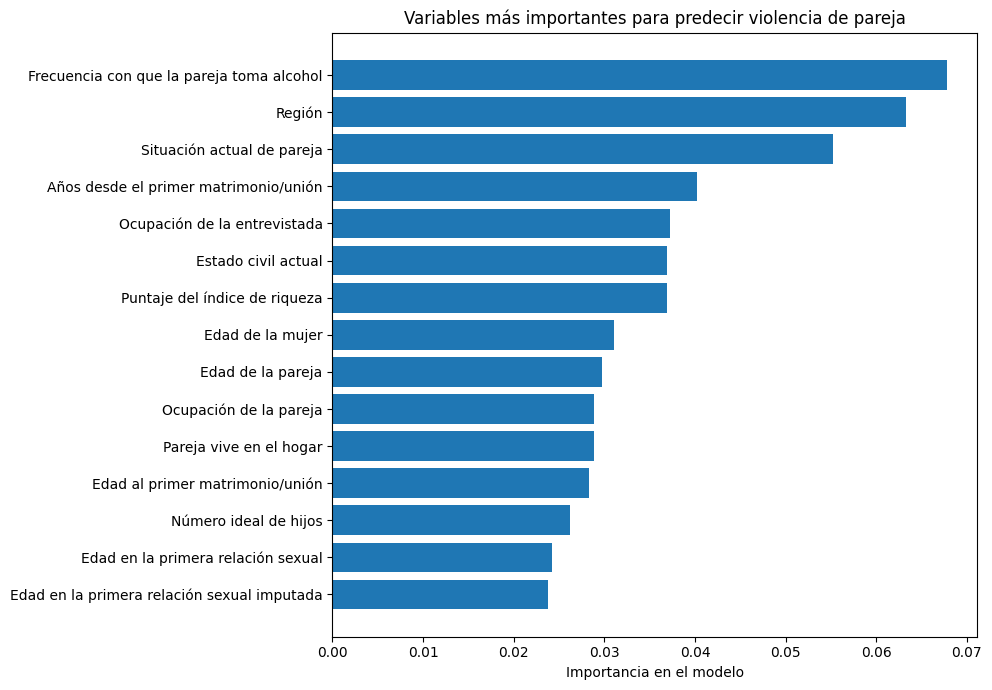

In [ ]:
# ============================================================
# 29. GRÁFICO DE BARRAS: VARIABLES MÁS IMPORTANTES DEL MODELO
# ============================================================

import matplotlib.pyplot as plt

# Diccionario de nombres descriptivos
nombres_variables = {
    "D113": "Pareja toma alcohol",
    "D114": "Frecuencia con que la pareja toma alcohol",
    "V501": "Estado civil actual",
    "V502": "Situación actual de pareja",
    "V503": "Número de uniones",
    "V504": "Pareja vive en el hogar",
    "V511": "Edad al primer matrimonio/unión",
    "V512": "Años desde el primer matrimonio/unión",
    "V513": "Duración del matrimonio/unión",
    "V525": "Edad en la primera relación sexual",
    "V531": "Edad en la primera relación sexual imputada",
    "V602": "Deseo de tener más hijos",
    "V605": "Tiempo ideal para próximo hijo",
    "V613": "Número ideal de hijos",
    "V701": "Educación de la pareja",
    "V705": "Ocupación de la pareja",
    "V729": "Nivel educativo de la pareja",
    "V730": "Edad de la pareja",
    "V714": "Actualmente trabaja",
    "V716": "Ocupación de la entrevistada",
    "V731": "Trabajó en los últimos 12 meses",
    "V741": "Tipo de ingresos por trabajo",
    "V746": "Gana más, menos o igual que su pareja",
    "V012": "Edad de la mujer",
    "V013": "Grupo de edad",
    "V024": "Región",
    "V025": "Área de residencia",
    "V102": "Tipo de lugar de residencia",
    "V103": "Lugar de residencia en la infancia",
    "V106": "Nivel educativo de la mujer",
    "V107": "Año/grado educativo aprobado",
    "V133": "Años de educación",
    "V131": "Etnicidad",
    "V190": "Índice de riqueza",
    "V191": "Puntaje del índice de riqueza",
    "V044": "Selección módulo violencia doméstica",
    "ANIO": "Año de encuesta",
    "V001": "Conglomerado",
    "V002": "Número de hogar",
    "V003": "Línea de la entrevistada",
    "V005": "Peso muestral"
}

# Copiamos la tabla de importancias agregadas
grafico_importancias = importancias_variable_final.copy()

# Agregamos nombre descriptivo
grafico_importancias["nombre_variable"] = grafico_importancias["variable_original"].map(nombres_variables)

# Si alguna variable no está en el diccionario, mantenemos el código original
grafico_importancias["nombre_variable"] = grafico_importancias["nombre_variable"].fillna(
    grafico_importancias["variable_original"]
)

# Para la presentación, recomiendo excluir variables administrativas
variables_admin = ["V001", "V002", "V003", "V005", "V044"]

grafico_importancias_plot = grafico_importancias[
    ~grafico_importancias["variable_original"].isin(variables_admin)
].copy()

# Elegimos Top 15
top_n = 15
top_importancias = grafico_importancias_plot.head(top_n).copy()

# Ordenamos de menor a mayor para que el gráfico horizontal salga bonito
top_importancias = top_importancias.sort_values("importancia", ascending=True)

# Gráfico
plt.figure(figsize=(10, 7))
plt.barh(
    top_importancias["nombre_variable"],
    top_importancias["importancia"]
)

plt.xlabel("Importancia en el modelo")
plt.ylabel("")
plt.title("Variables más importantes para predecir violencia de pareja")
plt.tight_layout()
plt.show()

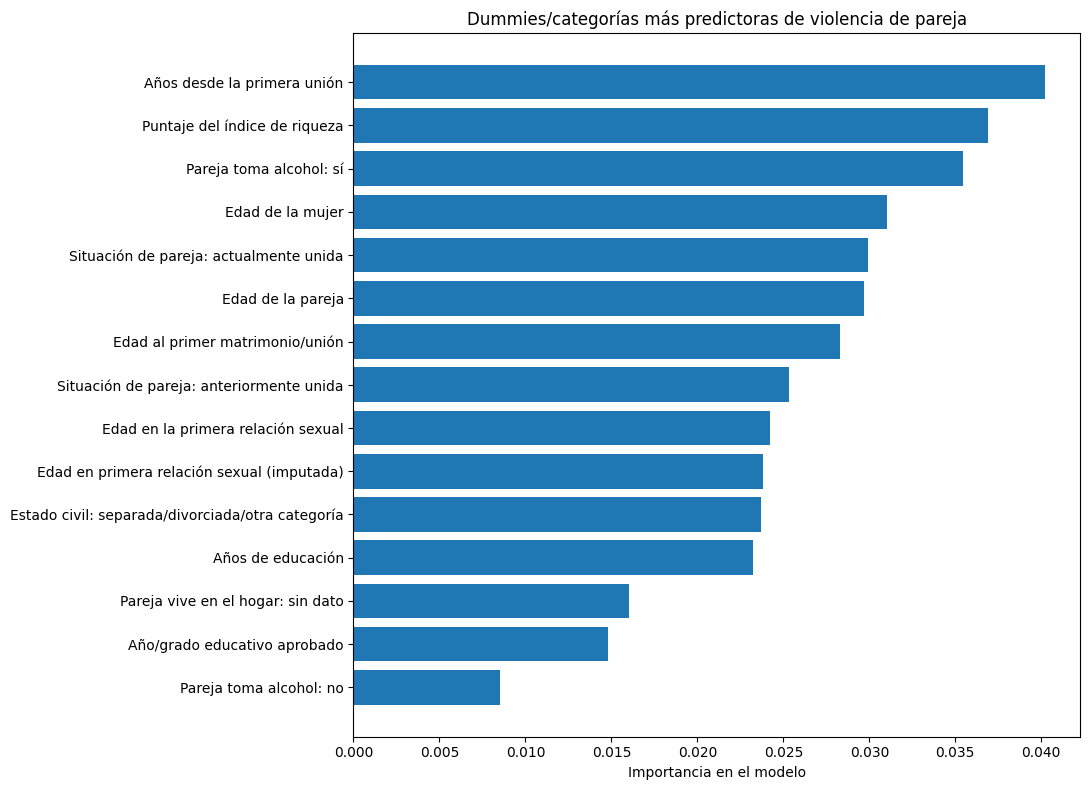

In [ ]:
# ============================================================
# 32. GRÁFICO DE BARRAS: TOP DUMMIES MÁS IMPORTANTES
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

# Copia de la tabla
grafico_dummies = importancias_dummy_final.copy()

# Excluir variables administrativas / técnicas
excluir_prefix = ["V001", "V002", "V003", "V005"]

grafico_dummies = grafico_dummies[
    ~grafico_dummies["variable_dummy"].str.startswith(tuple(excluir_prefix))
].copy()

# Diccionario para poner etiquetas más legibles
nombres_dummies = {
    "D114_1": "Pareja toma alcohol: sí",
    "D114_1.0": "Pareja toma alcohol: sí",
    "D114_0": "Pareja toma alcohol: no",
    "D114_2": "Pareja toma alcohol: a veces / otra categoría",
    "D114_ ": "Pareja toma alcohol: sin dato",

    "D113_0": "Pareja se embriaga: no",

    "V502_1.0": "Situación de pareja: actualmente unida",
    "V502_2.0": "Situación de pareja: anteriormente unida",

    "V501_1.0": "Estado civil: casada",
    "V501_2.0": "Estado civil: conviviente",
    "V501_5.0": "Estado civil: separada/divorciada/otra categoría",

    "V504_1": "Pareja vive en el hogar: sí",
    "V504_ ": "Pareja vive en el hogar: sin dato",

    "V513_1": "Duración de unión: categoría 1",

    "V190_2.0": "Quintil de riqueza: pobre",
    "V190_3.0": "Quintil de riqueza: medio",

    "V613_2": "Número ideal de hijos: categoría 2",

    "V512": "Años desde la primera unión",
    "V191": "Puntaje del índice de riqueza",
    "V012": "Edad de la mujer",
    "V730": "Edad de la pareja",
    "V511": "Edad al primer matrimonio/unión",
    "V525": "Edad en la primera relación sexual",
    "V531": "Edad en primera relación sexual (imputada)",
    "V133": "Años de educación",
    "V107": "Año/grado educativo aprobado"
}

# Si no está en el diccionario, dejamos el código original
grafico_dummies["etiqueta"] = grafico_dummies["variable_dummy"].map(nombres_dummies)
grafico_dummies["etiqueta"] = grafico_dummies["etiqueta"].fillna(grafico_dummies["variable_dummy"])

# Elegir top N
top_n = 15
top_dummies = grafico_dummies.head(top_n).copy()

# Ordenar para gráfico horizontal
top_dummies = top_dummies.sort_values("importancia", ascending=True)

# Graficar
plt.figure(figsize=(11, 8))
plt.barh(top_dummies["etiqueta"], top_dummies["importancia"])
plt.xlabel("Importancia en el modelo")
plt.ylabel("")
plt.title("Dummies/categorías más predictoras de violencia de pareja")
plt.tight_layout()
plt.show()

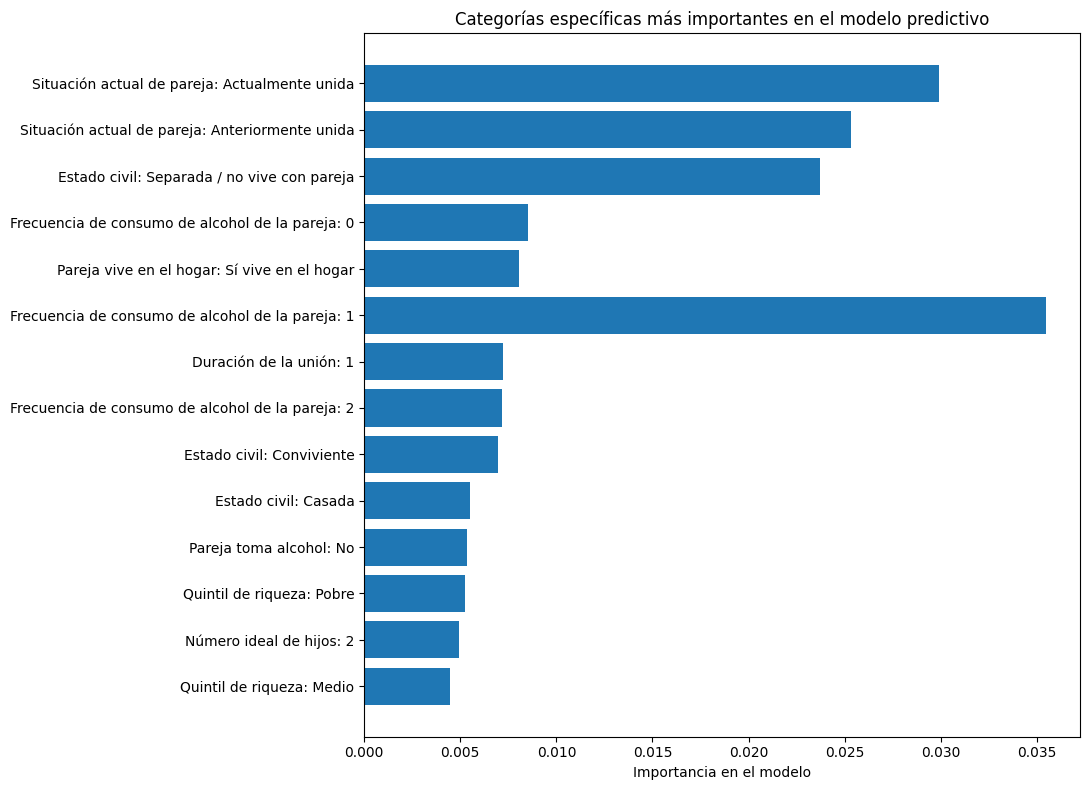

In [ ]:
# ============================================================
# GRÁFICO SOLO DE DUMMIES / CATEGORÍAS
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

# Copia de importancias
df_dummies = importancias_dummy_final.copy()

# Separar variable original y categoría
def separar_variable_categoria(nombre):
    if "_" in nombre:
        var, cat = nombre.split("_", 1)
        return var, cat
    else:
        return nombre, ""

df_dummies[["variable_original", "categoria"]] = df_dummies["variable_dummy"].apply(
    lambda x: pd.Series(separar_variable_categoria(x))
)

# Limpiar categorías tipo 1.0 -> 1
def limpiar_categoria(cat):
    cat = str(cat).strip()
    try:
        num = float(cat)
        if num.is_integer():
            return str(int(num))
        else:
            return str(num)
    except:
        return cat

df_dummies["categoria_limpia"] = df_dummies["categoria"].apply(limpiar_categoria)

# Excluir variables numéricas y administrativas
variables_admin = ["V001", "V002", "V003", "V005", "V044"]
df_dummies = df_dummies[
    ~df_dummies["variable_dummy"].isin(num_vars)
].copy()

df_dummies = df_dummies[
    ~df_dummies["variable_original"].isin(variables_admin)
].copy()

# Opcional: excluir categorías vacías / sin dato
df_dummies = df_dummies[
    df_dummies["categoria_limpia"].str.strip() != ""
].copy()

# Diccionario de nombres de variables
nombres_variables = {
    "D113": "Pareja toma alcohol",
    "D114": "Frecuencia de consumo de alcohol de la pareja",
    "V501": "Estado civil",
    "V502": "Situación actual de pareja",
    "V503": "Número de uniones",
    "V504": "Pareja vive en el hogar",
    "V513": "Duración de la unión",
    "V602": "Deseo de tener más hijos",
    "V605": "Tiempo ideal para próximo hijo",
    "V613": "Número ideal de hijos",
    "V701": "Educación de la pareja",
    "V705": "Ocupación de la pareja",
    "V729": "Nivel educativo de la pareja",
    "V714": "Actualmente trabaja",
    "V716": "Ocupación de la mujer",
    "V731": "Trabajó en los últimos 12 meses",
    "V741": "Tipo de ingresos por trabajo",
    "V746": "Gana más, menos o igual que su pareja",
    "V013": "Grupo de edad",
    "V024": "Región",
    "V025": "Área de residencia",
    "V102": "Tipo de lugar de residencia",
    "V103": "Lugar de residencia en la infancia",
    "V106": "Nivel educativo de la mujer",
    "V131": "Etnicidad",
    "V190": "Quintil de riqueza",
    "ANIO": "Año de encuesta"
}

# Diccionario de algunas categorías importantes
nombres_categorias = {
    ("D114", "0"): "0",
    ("D114", "1"): "1",
    ("D114", "2"): "2",

    ("D113", "0"): "No",
    ("D113", "1"): "Sí",

    ("V502", "1"): "Actualmente unida",
    ("V502", "2"): "Anteriormente unida",

    ("V501", "1"): "Casada",
    ("V501", "2"): "Conviviente",
    ("V501", "5"): "Separada / no vive con pareja",

    ("V504", "1"): "Sí vive en el hogar",
    ("V504", "2"): "No vive en el hogar",

    ("V190", "1"): "Muy pobre",
    ("V190", "2"): "Pobre",
    ("V190", "3"): "Medio",
    ("V190", "4"): "Rico",
    ("V190", "5"): "Muy rico"
}

# Crear etiqueta final
def crear_etiqueta(row):
    var = row["variable_original"]
    cat = row["categoria_limpia"]

    nombre_var = nombres_variables.get(var, var)
    nombre_cat = nombres_categorias.get((var, cat), cat)

    return f"{nombre_var}: {nombre_cat}"

df_dummies["etiqueta"] = df_dummies.apply(crear_etiqueta, axis=1)

# Ordenar por importancia
df_dummies = df_dummies.sort_values("importancia", ascending=False)

# Top 15
top_n = 15
top_dummies = df_dummies.head(top_n).copy()

# Ordenar para gráfico horizontal
top_dummies = top_dummies.sort_values("importancia", ascending=True)

# Graficar
plt.figure(figsize=(11, 8))
plt.barh(top_dummies["etiqueta"], top_dummies["importancia"])

plt.xlabel("Importancia en el modelo")
plt.ylabel("")
plt.title("Categorías específicas más importantes en el modelo predictivo")
plt.tight_layout()
plt.show()

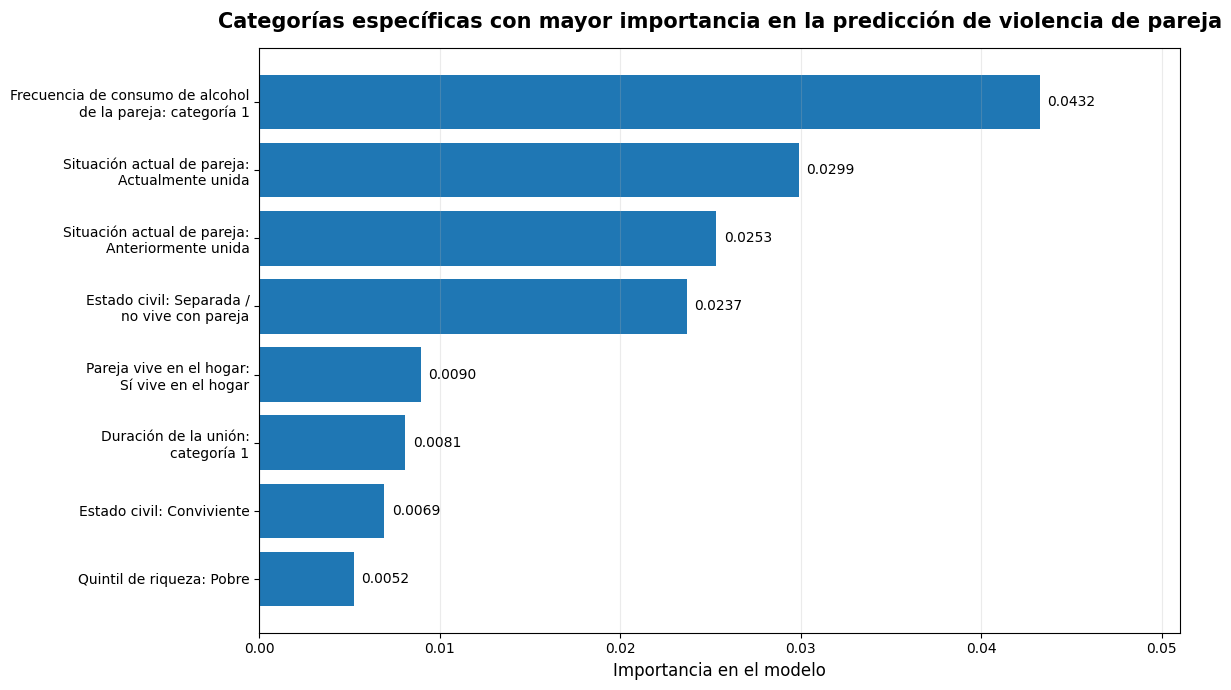

In [ ]:
# ============================================================
# GRÁFICO CURADO: CATEGORÍAS ESPECÍFICAS MÁS IMPORTANTES
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Copiamos la tabla de importancias por dummy
df_plot = importancias_dummy_final.copy()

# ------------------------------------------------------------
# 1. Limpiar nombres de dummies
# ------------------------------------------------------------

def separar_variable_categoria(nombre):
    if "_" in nombre:
        var, cat = nombre.split("_", 1)
        return var, cat
    else:
        return nombre, ""

df_plot[["variable_original", "categoria"]] = df_plot["variable_dummy"].apply(
    lambda x: pd.Series(separar_variable_categoria(x))
)

def limpiar_categoria(cat):
    cat = str(cat).strip()
    try:
        num = float(cat)
        if num.is_integer():
            return str(int(num))
        else:
            return str(num)
    except:
        return cat

df_plot["categoria_limpia"] = df_plot["categoria"].apply(limpiar_categoria)

# Creamos identificador limpio tipo V502_1, V501_5, etc.
df_plot["dummy_limpia"] = df_plot["variable_original"] + "_" + df_plot["categoria_limpia"]

# ------------------------------------------------------------
# 2. Agrupar por dummy limpia
#    Esto corrige casos como D114_1 y D114_1.0
# ------------------------------------------------------------

df_plot_limpio = df_plot.groupby("dummy_limpia", as_index=False)["importancia"].sum()

# ------------------------------------------------------------
# 3. Elegir categorías que queremos mostrar en la exposición
# ------------------------------------------------------------

categorias_seleccionadas = {
    "D114_1": "Frecuencia de consumo de alcohol\nde la pareja: categoría 1",
    "V502_1": "Situación actual de pareja:\nActualmente unida",
    "V502_2": "Situación actual de pareja:\nAnteriormente unida",
    "V501_5": "Estado civil: Separada /\nno vive con pareja",
    "V504_1": "Pareja vive en el hogar:\nSí vive en el hogar",
    "V513_1": "Duración de la unión:\ncategoría 1",
    "V501_2": "Estado civil: Conviviente",
    "V190_2": "Quintil de riqueza: Pobre"
}

grafico_final = df_plot_limpio[
    df_plot_limpio["dummy_limpia"].isin(categorias_seleccionadas.keys())
].copy()

grafico_final["etiqueta"] = grafico_final["dummy_limpia"].map(categorias_seleccionadas)

# Ordenar de mayor a menor importancia
grafico_final = grafico_final.sort_values("importancia", ascending=False)

# Para gráfico horizontal, invertimos el orden
grafico_final_plot = grafico_final.sort_values("importancia", ascending=True)

# ------------------------------------------------------------
# 4. Graficar
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

bars = plt.barh(
    grafico_final_plot["etiqueta"],
    grafico_final_plot["importancia"]
)

plt.xlabel("Importancia en el modelo", fontsize=12)
plt.title(
    "Categorías específicas con mayor importancia en la predicción de violencia de pareja",
    fontsize=15,
    fontweight="bold",
    pad=15
)

# Etiquetas numéricas al final de cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.0004,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.4f}",
        va="center",
        fontsize=10
    )

plt.xlim(0, grafico_final_plot["importancia"].max() * 1.18)
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

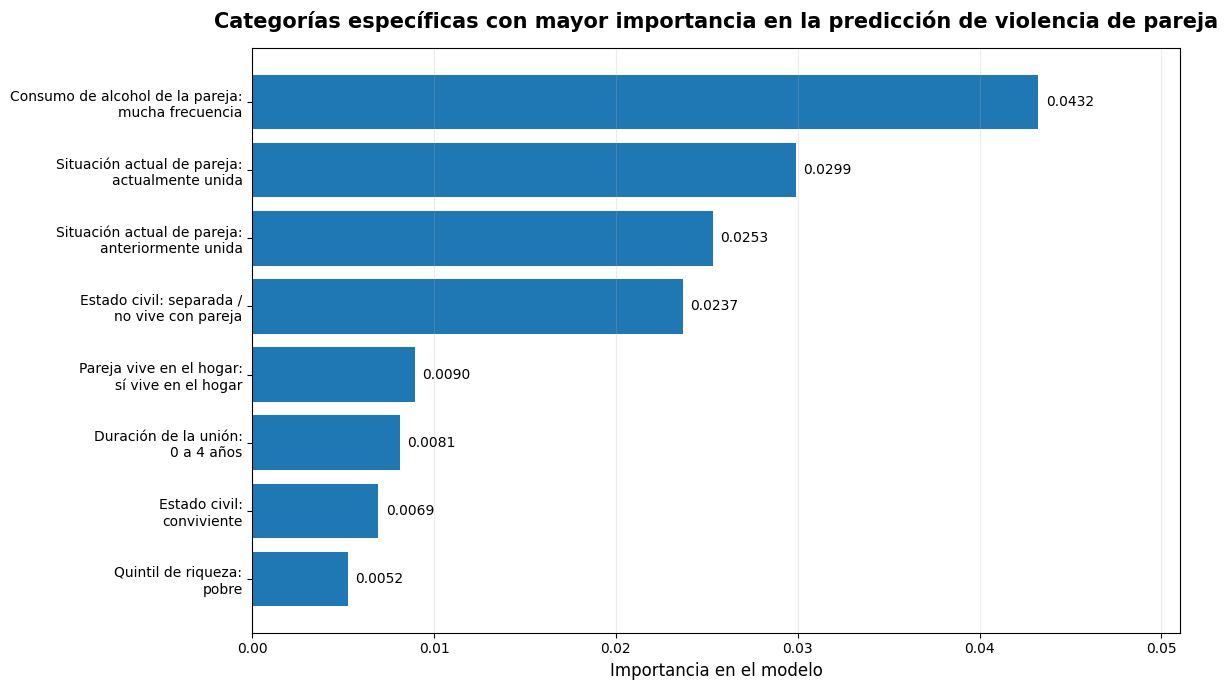

In [ ]:
# ============================================================
# GRÁFICO CURADO: CATEGORÍAS ESPECÍFICAS MÁS IMPORTANTES
# Versión con etiquetas interpretables
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Copiamos la tabla de importancias por dummy
df_plot = importancias_dummy_final.copy()

# ------------------------------------------------------------
# 1. Separar variable y categoría
# ------------------------------------------------------------

def separar_variable_categoria(nombre):
    if "_" in nombre:
        var, cat = nombre.split("_", 1)
        return var, cat
    else:
        return nombre, ""

df_plot[["variable_original", "categoria"]] = df_plot["variable_dummy"].apply(
    lambda x: pd.Series(separar_variable_categoria(x))
)

# Limpiar categorías: 1.0 -> 1, 2.0 -> 2, etc.
def limpiar_categoria(cat):
    cat = str(cat).strip()
    try:
        num = float(cat)
        if num.is_integer():
            return str(int(num))
        else:
            return str(num)
    except:
        return cat

df_plot["categoria_limpia"] = df_plot["categoria"].apply(limpiar_categoria)

# Crear dummy limpia: D114_1, V502_1, etc.
df_plot["dummy_limpia"] = df_plot["variable_original"] + "_" + df_plot["categoria_limpia"]

# ------------------------------------------------------------
# 2. Agrupar duplicados generados por 1 y 1.0
# ------------------------------------------------------------

df_plot_limpio = df_plot.groupby(
    "dummy_limpia",
    as_index=False
)["importancia"].sum()

# ------------------------------------------------------------
# 3. Categorías seleccionadas para la exposición
# ------------------------------------------------------------

categorias_seleccionadas = {
    "D114_1": "Consumo de alcohol de la pareja:\nmucha frecuencia",
    "V502_1": "Situación actual de pareja:\nactualmente unida",
    "V502_2": "Situación actual de pareja:\nanteriormente unida",
    "V501_5": "Estado civil: separada /\nno vive con pareja",
    "V504_1": "Pareja vive en el hogar:\nsí vive en el hogar",
    "V513_1": "Duración de la unión:\n0 a 4 años",
    "V501_2": "Estado civil:\nconviviente",
    "V190_2": "Quintil de riqueza:\npobre"
}

grafico_final = df_plot_limpio[
    df_plot_limpio["dummy_limpia"].isin(categorias_seleccionadas.keys())
].copy()

grafico_final["etiqueta"] = grafico_final["dummy_limpia"].map(categorias_seleccionadas)

# Ordenar de mayor a menor
grafico_final = grafico_final.sort_values("importancia", ascending=False)

# Para gráfico horizontal, se ordena de menor a mayor
grafico_final_plot = grafico_final.sort_values("importancia", ascending=True)

# ------------------------------------------------------------
# 4. Graficar
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

bars = plt.barh(
    grafico_final_plot["etiqueta"],
    grafico_final_plot["importancia"]
)

plt.xlabel("Importancia en el modelo", fontsize=12)
plt.title(
    "Categorías específicas con mayor importancia en la predicción de violencia de pareja",
    fontsize=15,
    fontweight="bold",
    pad=15
)

# Valores al final de cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.0004,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.4f}",
        va="center",
        fontsize=10
    )

plt.xlim(0, grafico_final_plot["importancia"].max() * 1.18)
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()